## Setup

In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

from utils.general_utils import (PROJECT_ROOT, SPECIES_COLORS,
                                 species_label, target_config)

N_BINS = 6

TARGET    = "photon"       # "pion" | "photon"
MODEL_SET = "all8"         # "base4" | "all8"
cfg = target_config(TARGET)

TRACKS_PATH = PROJECT_ROOT / "prepared" / "prepared-mc" / "test_tracks.pkl"
with open(TRACKS_PATH, "rb") as f:
    tracks = pickle.load(f)
species = np.array([species_label(t) for t in tracks])

PRED_DIR = PROJECT_ROOT / "predictions" / "predictions-mc"
MODELS = [
    (f"Hybrid {MODEL_SET}",
     PRED_DIR / f"hybrid_cnn_mlp_{MODEL_SET}{cfg['suffix']}.pkl", "crimson"),
]

# beam_KE is the kinetic energy of the incoming beam pion, derived from the
# beam instrumentation momentum. It replaces track_length and shower_energy,
# which described the final-state object rather than the beam, and is the
# variable behind the energy-dependence question raised on 29 July.
#
# It is per EVENT, so every PFO in an event shares a value: binning by it is
# binning by event, and the bins are not independent at PFO level.
ENERGY_KEY   = 'beam_KE'
ENERGY_LABEL = 'beam kinetic energy [MeV]'

PLOTS_DIR = PROJECT_ROOT / "plots" / "energy-study" / TARGET
PLOTS_DIR.mkdir(parents=True, exist_ok=True)


def metrics(pred, lab):
    tp = np.sum((pred == 1) & (lab == 1)); fn = np.sum((pred == 0) & (lab == 1))
    fp = np.sum((pred == 1) & (lab == 0)); tn = np.sum((pred == 0) & (lab == 0))
    return (tp / (tp + fn) if tp + fn else np.nan,
            tp / (tp + fp) if tp + fp else np.nan,
            fp / (fp + tn) if fp + tn else np.nan)


def bin_by_energy(energy, n_bins=N_BINS, pct_clip=(0.5, 99.5)):
    """Trim outliers and bin `energy` into `n_bins` quantile bins.

    The clip matters for beam_KE: beam instrumentation mismeasurement puts a
    few events above 5 GeV on a 2 GeV beam.
    """
    lo_c, hi_c = np.nanpercentile(energy, pct_clip)
    good = np.isfinite(energy) & (energy >= lo_c) & (energy <= hi_c)
    print(f"kept {good.sum():,}/{len(energy):,} PFOs ({lo_c:.0f}-{hi_c:.0f}; "
          f"{(~good).sum():,} outliers dropped)")
    edges = np.unique(np.quantile(energy[good], np.linspace(0, 1, n_bins + 1)))
    xlab = [f"{edges[i]:.0f}-{edges[i+1]:.0f}" for i in range(len(edges) - 1)]
    xpos = np.arange(len(edges) - 1)
    return good, edges, xlab, xpos


def plot_perf_vs_energy(energy, good, edges, xlab, xpos, xaxis_label, out_path):
    fig, ax = plt.subplots(1, 3, figsize=(16, 4.8), dpi=150)
    for name, path, col in MODELS:
        with open(path, "rb") as f:
            d = pickle.load(f)
        probs  = np.asarray(d["probs"])
        labels = np.asarray(d["labels"]).astype(int)
        thr    = d["threshold"]
        preds  = (probs >= thr).astype(int)
        effs, purs, fprs = [], [], []
        for i in range(len(xpos)):
            m = good & (energy >= edges[i]) & (energy < edges[i + 1])
            e, p, f_ = metrics(preds[m], labels[m])
            effs.append(e); purs.append(p); fprs.append(f_)
        ax[0].plot(xpos, effs, "o-", color=col, label=name)
        ax[1].plot(xpos, purs, "o-", color=col, label=name)
        ax[2].plot(xpos, fprs, "o-", color=col, label=name)

    for a, t in zip(ax, ["Efficiency (recall)  ↑ better",
                         "Purity (precision)  ↑ better",
                         "False positive rate  ↓ better"]):
        a.set_title(t); a.set_xlabel(xaxis_label)
        a.set_xticks(xpos); a.set_xticklabels(xlab, rotation=30, ha="right", fontsize=8)
        a.grid(alpha=0.3); a.legend(fontsize=9)
    ax[0].set_ylim(0, 1); ax[1].set_ylim(0, 1); ax[2].set_ylim(bottom=0)
    plt.suptitle(f"{cfg['signal_name']} selection vs {xaxis_label}", y=1.02)
    plt.tight_layout()
    plt.savefig(out_path, bbox_inches="tight")
    plt.show()
    print(f"Saved {out_path}")


print(f"target: {TARGET}   model: {MODEL_SET}   energy: {ENERGY_KEY}")

## Energy proxy version

kept 125,547/126,817 PFOs (1-506; 1,270 outliers dropped)


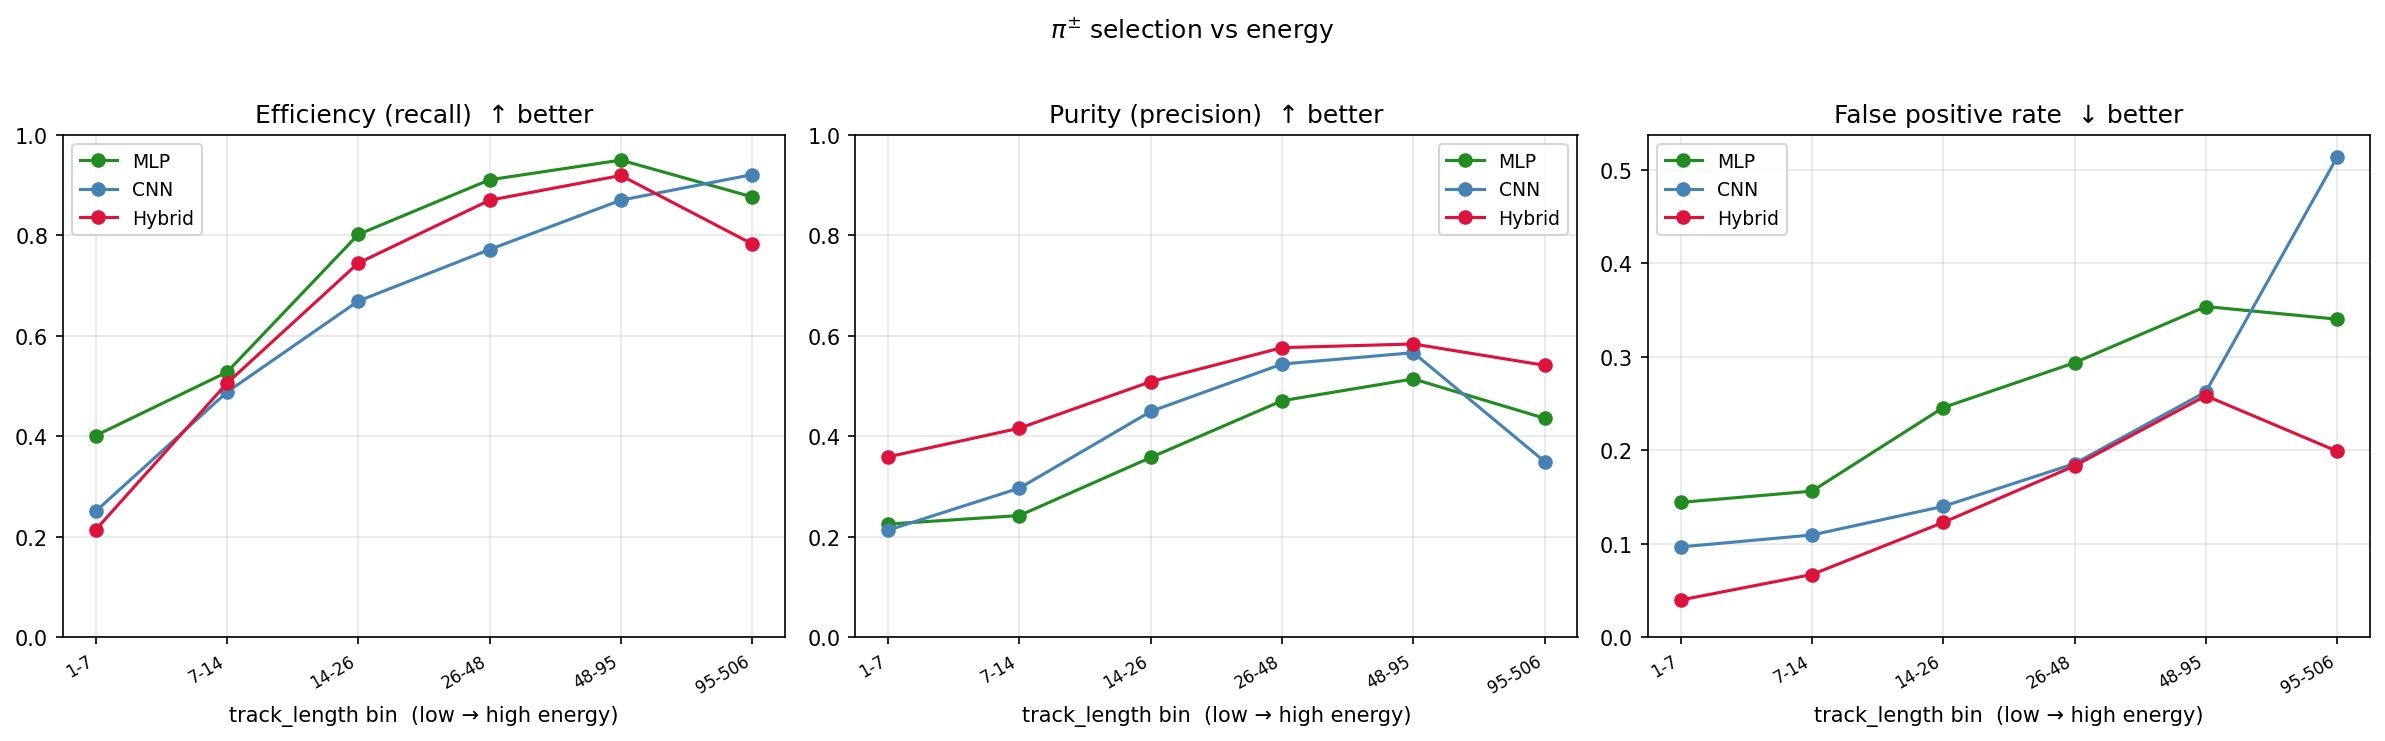

Saved /home/pemb7173/PDSP-pion-classification/plots/energy-study/perf_vs_energy_pion.png


In [ ]:
# performance vs the target's energy proxy (see ENERGY_KEY in setup)
energy = np.array([float(t[ENERGY_KEY]) for t in tracks])
good, edges, xlab, xpos = bin_by_energy(energy)

plot_perf_vs_energy(
    energy, good, edges, xlab, xpos, ENERGY_LABEL,
    out_path=PLOTS_DIR / f"perf_vs_beamKE_{MODEL_SET}_{TARGET}.pdf",
)